
# Hankel-Rank-Regularised DQN (HR-DQN) on CartPole-v1

This notebook loads [config_hankel.yaml](config_hankel.yaml) and benchmarks
`HankelDQNAgent` — the classical (Double-)DQN loss plus a **truncated-nuclear-norm
penalty on Hankel matrices of predicted Q-values along replayed sub-trajectory
windows** (see [docs/hankel_regularised_dqn.md](../../docs/hankel_regularised_dqn.md)
for the maths). At `hankel_weight: 0` the agent reproduces `QAgent` training exactly,
so the `baseline` variant *is* the classical DQN through the identical pipeline.

Grid: `baseline` (λ=0 — exact classical QAgent), `config` (config_hankel.yaml as-is),
`winning` (`progress_order2`, the speed-campaign winner from
[docs/hankel_speedup_campaign.md](../../docs/hankel_speedup_campaign.md): r=2, λ=1e-2,
gate ρ=0.25, progress-conditioned engagement at rolling-10 return ≥ 100, ramp 2000)
× seeds 0–3, cached as `results_hankel/<variant>_s<seed>.npz`. The cache is
config-aware: each npz stores the resolved config that produced it, and a run
re-runs automatically when that no longer matches the current yaml + overrides
(deleting a file still forces a re-run). Note a base-config edit invalidates
*all* variants — `baseline`/`winning` only pin their hankel keys and inherit the
rest.

## Imports

In [8]:
import csv, json, pathlib, random, shutil, sys, time

import numpy as np
import torch
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from experiment import load_config, build_env, build_agent, train, make_run_logger
from agents.hankel_dqn_agent import HankelDQNAgent
from agents.hankel_regulariser import HankelRankPenalty
from analysis.low_rank.hankel_policy import collect_hankel_sequences, _hankel_from_sequence
from analysis.low_rank.rank import compute_rank_metrics
from analysis.run_logger import RunLogger
from training import _greedy_episode_return

## Mechanism demo: the penalty measures (and can descend) rank-2 violation

penalty  rank-2: 0.00e+00 (eff-rank 2.0)   noise: 0.573 (eff-rank 4.9)


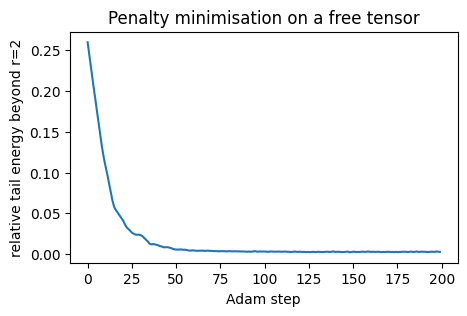

In [9]:
# Rank-2 signals (exact order-2 recurrence: damped oscillations) get ~zero penalty;
# white noise gets a large one — and gradient descent on the penalty alone drives a
# noisy sequence back toward the rank-2 manifold with finite gradients throughout.
def rank2_batch(B=8, T=16):
    t = torch.arange(T, dtype=torch.float64)
    return torch.stack([(0.95 + 0.004 * i) ** t * (1.5 * torch.cos((0.3 + 0.05 * i) * t)
                                                   + 0.5 * torch.sin((0.3 + 0.05 * i) * t))
                        for i in range(B)]).float()

pen = HankelRankPenalty(order=2)
p_clean, d_clean = pen(rank2_batch())
torch.manual_seed(0)
p_noise, d_noise = pen(torch.randn(8, 16))
print(f"penalty  rank-2: {float(p_clean):.2e} (eff-rank {d_clean['batch_eff_rank']:.1f})   "
      f"noise: {float(p_noise):.3f} (eff-rank {d_noise['batch_eff_rank']:.1f})")

x = (rank2_batch() + 0.3 * torch.randn(8, 16)).clone().requires_grad_(True)
opt, curve = torch.optim.Adam([x], lr=0.02), []
for _ in range(200):
    opt.zero_grad(); p, _ = pen(x); p.backward(); opt.step(); curve.append(float(p))
plt.figure(figsize=(5, 3)); plt.plot(curve)
plt.xlabel("Adam step"); plt.ylabel("relative tail energy beyond r=2")
plt.title("Penalty minimisation on a free tensor"); plt.show()

## Config

In [10]:
cfg = load_config("config_hankel.yaml")
print("device:", cfg["experiment"]["_device"])
cfg["agent"]

device: cuda


{'replay_buffer_capacity': 100000,
 'batch_size': 128,
 'nn_learning_rate': 0.00025,
 'eps_start': 1.0,
 'eps_min': 0.05,
 'decay_rate': 0.99992,
 'discount_factor': 0.99,
 'TD_LR': 0.005,
 'buffer_util': 1,
 'gd_steps_ceil': 1,
 'grad_clip_norm': 60.0,
 'double': True,
 'hankel_weight': 1,
 'hankel_order': 1,
 'window_len': 16,
 'n_windows': 16,
 'gate_threshold': None,
 'warmup_grad_steps': 0,
 'ramp_grad_steps': 1,
 'window_half_life': 20}

## Environment and Q-network

In [11]:
env0 = build_env(cfg)
print("obs_dim:", env0.observation_space.shape[0], "n_actions:", env0.action_space.n)
env0.close()

obs_dim: 4 n_actions: 2


In [12]:
class QNetwork(torch.nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by the agent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [torch.nn.Linear(last, h), torch.nn.ReLU()]
            last = h
        layers.append(torch.nn.Linear(last, out_dim))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Benchmark: variants × seeds (cached)

In [13]:
ENV_NAME = "CartPole-v1"

In [14]:
VARIANTS = {
    "baseline": dict(hankel_weight=0.0),   # hankel_weight 0 => exact QAgent / classical DQN
    "config":   dict(),                    # config_hankel.yaml as-is
    # progress_order2 — the speed-campaign winner (docs/hankel_speedup_campaign.md,
    # rounds 4-5): measured rank r=2, λ=1e-2, gate ρ=0.25, penalty latched on when
    # the rolling-10 episode return crosses 100, ramp 2000 from the latch (the
    # progress latch replaces the grad-step warm-up clock).
    "winning":  dict(hankel_weight=1e-2, hankel_order=2, gate_threshold=0.25,
                     warmup_grad_steps=0, ramp_grad_steps=2000,
                     engage_reward_threshold=100, engage_reward_window=10),
}
SEEDS = [0, 1, 2, 3]
RESULTS = pathlib.Path("results_hankel")
RESULTS.mkdir(exist_ok=True)


def resolve_cfg(overrides, seed):
    """The exact config a benchmark run uses (yaml + variant overrides + seed)."""
    cfg = load_config("config_hankel.yaml")
    cfg["experiment"]["seed"] = seed
    cfg["agent"].update(overrides)
    # No rank/spectra analysis inside benchmark runs, but keep a 25-episode tick
    # so rewards.csv / checkpoints refresh and the run is watchable live in the
    # result viewer app (runs/<variant>_s<seed>/).
    cfg["analysis"] = {"ep_freq": 25, "methods": []}
    return cfg


def cache_key(cfg):
    """Canonical JSON of every config section that determines the run's outcome
    (device is deliberately excluded), stored inside the npz so a run re-runs
    automatically when the config that produced it no longer matches."""
    parts = {k: cfg[k] for k in ("environment", "network", "agent", "training")}
    parts["seed"] = cfg["experiment"]["seed"]
    return json.dumps(parts, sort_keys=True, default=str)


def is_cached(out_path, key):
    if not out_path.exists():
        return False
    with np.load(out_path) as d:
        return "cfg_json" in d.files and str(d["cfg_json"]) == key


def run_one(cfg, out_path, run_id, key):
    seed = cfg["experiment"]["seed"]
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = build_env(cfg)
    nn_extra = {"in_dim": env.observation_space.shape[0], "out_dim": env.action_space.n,
                "hidden_sizes": cfg["network"]["hidden_sizes"]}
    agent = build_agent(cfg, env, q_network=QNetwork, nn_extra_kwargs=nn_extra,
                        agent_cls=HankelDQNAgent)
    diags = []
    def train_hook(_orig=agent.train):
        d = _orig()
        if d is not None:
            diags.append(d)
        return d
    agent.train = train_hook

    run_dir = pathlib.Path.cwd() / "runs" / run_id
    if run_dir.exists():
        shutil.rmtree(run_dir)  # stale logs from an interrupted/old-config run
    logger = RunLogger(pathlib.Path.cwd(), config_path="config_hankel.yaml", run_id=run_id)
    rewards = train(cfg, agent, env, run_logger=logger)

    eps = agent.epsilon
    agent.epsilon = 0.0  # greedy eval + on-policy probe
    evals = [_greedy_episode_return(agent, env, seed=30_000 + i) for i in range(20)]
    seqs = collect_hankel_sequences(agent, env, seed=777)
    eff_rank_q = compute_rank_metrics(_hankel_from_sequence(np.asarray(seqs["Hankel Q"])))[0]
    agent.epsilon = eps

    with open(logger.dir / "eval.csv", "w", newline="") as f:  # viewer eval tile
        w = csv.writer(f)
        w.writerow(["episode", "reward"])
        w.writerows(enumerate(evals))

    diag_arrays = ({f"diag_{k}": np.array([d[k] for d in diags], float) for k in diags[0]}
                   if diags else {})
    np.savez(out_path, rewards=np.array(rewards, float), evals=np.array(evals, float),
             eff_rank_q=eff_rank_q, nan_skips=agent.nan_skips, cfg_json=key,
             **diag_arrays)
    env.close()


for variant, ov in VARIANTS.items():
    for seed in SEEDS:
        out = RESULTS / f"{variant}_s{seed}.npz"
        cfg = resolve_cfg(ov, seed)
        key = cache_key(cfg)
        if is_cached(out, key):
            print("cached:", out.name)
            continue
        if out.exists():
            print("config changed, re-running:", out.name)
        t0 = time.time()
        run_one(cfg, out, run_id=f"{variant}_s{seed}", key=key)
        print(f"{out.name}: {time.time() - t0:.0f}s")

config changed, re-running: baseline_s0.npz


  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 20.0
episode 10 avg_rewarg: 20.2
episode 20 avg_rewarg: 19.5
episode 30 avg_rewarg: 20.8
episode 40 avg_rewarg: 24.1
episode 50 avg_rewarg: 25.9
episode 60 avg_rewarg: 14.9


  5%|▍         | 72/1500 [00:00<00:02, 712.87it/s]

episode 70 avg_rewarg: 24.4
episode 80 avg_rewarg: 17.0
episode 90 avg_rewarg: 19.6
episode 100 avg_rewarg: 22.2
episode 110 avg_rewarg: 18.8
episode 120 avg_rewarg: 20.9
episode 130 avg_rewarg: 30.5
episode 140 avg_rewarg: 32.7


...

episode 1480 avg_rewarg: 158.2


 99%|█████████▉| 1492/1500 [02:18<00:01,  7.08it/s]

episode 1490 avg_rewarg: 163.6


100%|██████████| 1500/1500 [02:19<00:00, 10.76it/s]


run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/winning_s3
winning_s3.npz: 140s


## Learning curves

In [15]:
data = {v: [np.load(RESULTS / f"{v}_s{s}.npz") for s in SEEDS] for v in VARIANTS}
COLORS = {"baseline": "tab:grey", "config": "tab:red", "winning": "tab:green"}

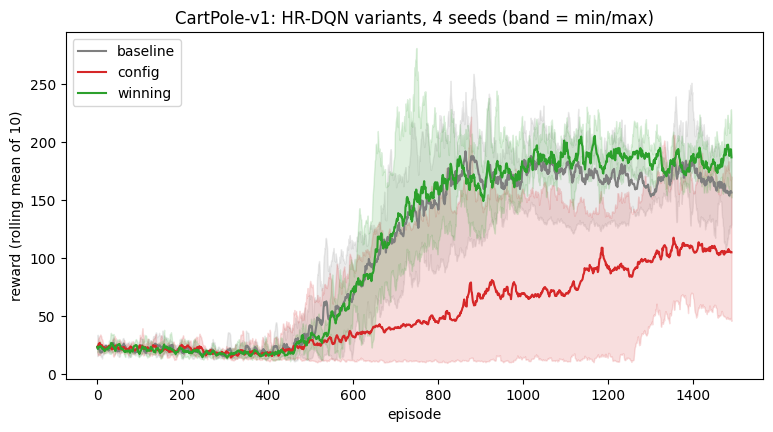

In [16]:
plt.figure(figsize=(9, 4.5))
for v, runs in data.items():
    L = min(len(r["rewards"]) for r in runs)
    R = np.stack([np.convolve(r["rewards"][:L], np.ones(10) / 10, "valid") for r in runs])
    m = R.mean(0)
    plt.plot(m, color=COLORS[v], label=v)
    plt.fill_between(range(len(m)), R.min(0), R.max(0), color=COLORS[v], alpha=0.15)
plt.xlabel("episode"); plt.ylabel("reward (rolling mean of 10)")
plt.title(f"{ENV_NAME}: HR-DQN variants, {len(SEEDS)} seeds (band = min/max)")
plt.legend(); plt.show()

## Final evaluation — 20 greedy episodes per run

In [17]:
print(f"{'variant':10s} {'eval20 mean±std':>22s} {'episodes to stop':>18s} {'final Hankel-Q eff-rank':>25s} {'nan_skips':>10s}")
for v, runs in data.items():
    means = np.array([r["evals"].mean() for r in runs])
    eps_used = [len(r["rewards"]) for r in runs]
    ranks = [int(r["eff_rank_q"]) for r in runs]
    skips = sum(int(r["nan_skips"]) for r in runs)
    print(f"{v:10s} {means.mean():13.1f} ± {means.std():5.1f} {str(eps_used):>18s} {str(ranks):>25s} {skips:>10d}")

variant           eval20 mean±std   episodes to stop   final Hankel-Q eff-rank  nan_skips
baseline           162.2 ±  19.0 [1500, 1500, 1500, 1500]              [1, 1, 1, 1]          0
config             114.5 ±  63.4 [1500, 1500, 1500, 1500]              [1, 1, 1, 1]          0
winning            183.2 ±  29.3 [1500, 1500, 1500, 1500]              [1, 1, 1, 1]          0


## Regulariser forensics

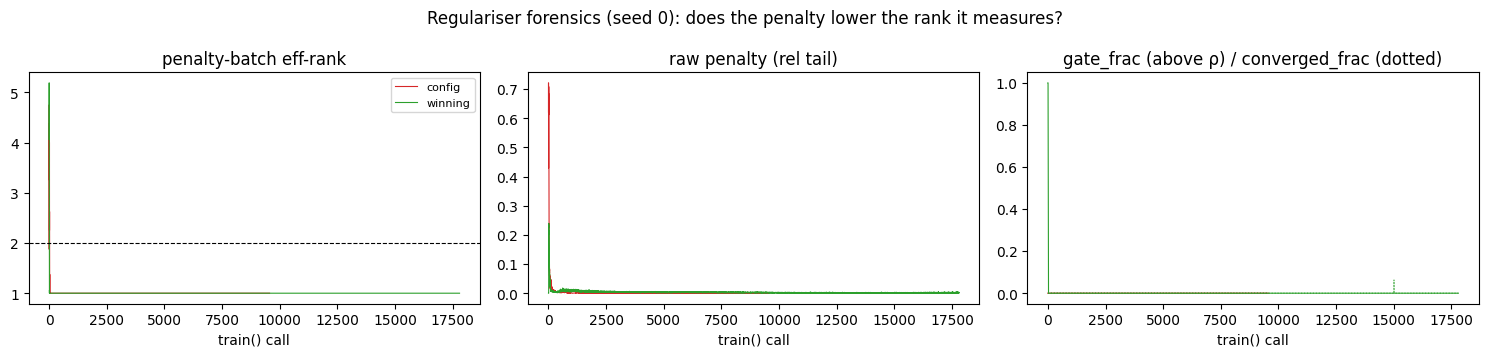

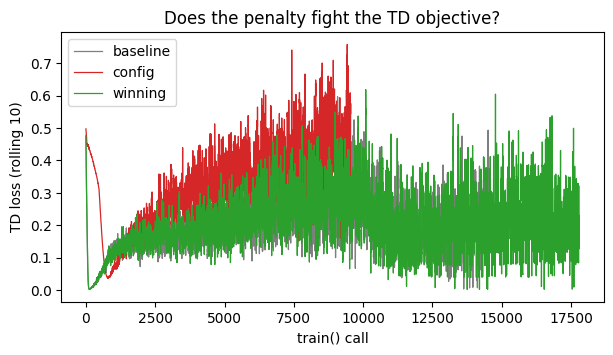

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for v, runs in data.items():
    for ax, key, lab in zip(axes, ["diag_batch_eff_rank", "diag_penalty_raw", "diag_gate_frac"],
                            ["penalty-batch eff-rank", "raw penalty (rel tail)",
                             "gate_frac (above ρ) / converged_frac (dotted)"]):
        r = runs[0]
        if key in r.files and not np.all(np.isnan(r[key])):
            ax.plot(r[key], color=COLORS[v], label=v, lw=0.8)
            if key == "diag_gate_frac" and "diag_converged_frac" in r.files:
                ax.plot(r["diag_converged_frac"], color=COLORS[v], ls=":", lw=0.8)
        ax.set_title(lab); ax.set_xlabel("train() call")
axes[0].axhline(2, ls="--", c="k", lw=0.8)
axes[0].legend(fontsize=8)
plt.suptitle("Regulariser forensics (seed 0): does the penalty lower the rank it measures?")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.5))
for v, runs in data.items():
    r = runs[0]
    if "diag_td_loss" in r.files:
        plt.plot(np.convolve(r["diag_td_loss"], np.ones(10) / 10, "valid"),
                 color=COLORS[v], label=v, lw=0.9)
plt.xlabel("train() call"); plt.ylabel("TD loss (rolling 10)"); plt.legend()
plt.title("Does the penalty fight the TD objective?"); plt.show()

## Findings

*(to fill in after the grid above has run — previous findings for the old
`tail_lo`/`tail_hi`/`gated`/`windows_lo` grid are in git history)*

Reference expectations for `winning` (`progress_order2`) from the N=20 speed
campaign ([docs/hankel_speedup_campaign.md](../../docs/hankel_speedup_campaign.md)):
AUC600 +27% over baseline (p = 0.0015), median solve −96 episodes (directional),
final eval unchanged. At N=4 seeds here, treat differences as directional only.

## Single instrumented run (optional)

For the full artifact trail (spectra figures, `hankel_sweep.csv` on-policy rank tracking,
`train_diagnostics.csv`, checkpoints under `runs/<timestamp>/`), run the canonical
single-experiment path with the config as-is:

```python
cfg = load_config("config_hankel.yaml")
env = build_env(cfg)
nn_extra = {"in_dim": env.observation_space.shape[0], "out_dim": env.action_space.n,
            "hidden_sizes": cfg["network"]["hidden_sizes"]}
agent = build_agent(cfg, env, q_network=QNetwork, nn_extra_kwargs=nn_extra, agent_cls=HankelDQNAgent)
logger = make_run_logger(cfg, config_path="config_hankel.yaml")
rewards = train(cfg, agent, env, run_logger=logger)
```